In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import pickle
import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"d:\Data Analytics & Data Science\NetMax Technologies\DataSet From claude\aqi_dataset.csv")
df.head()

,date,station,pm2_5,pm10,no2,so2,co,o3,nh3,temperature_c,humidity_pct,wind_speed_kmph,pressure_hpa,traffic_level,is_industrial_zone,aqi
0,2023-10-17,Delhi_ITO,140.34,227.75,44.46,21.66,1.187,38.81,14.02,25.57,64.3,8.03,1005.3,high,True,184.4
1,2023-08-21,Shimla_Sanjauli,3.00,15.34,17.13,10.26,0.424,64.81,14.99,26.26,85.0,5.78,1003.4,low,False,10.0
2,2023-05-11,Shimla_Sanjauli,12.30,35.38,23.51,10.20,0.916,38.49,17.20,21.96,58.0,4.92,1012.0,low,False,35.4
3,2023-01-19,Delhi_RKPuram,171.45,386.78,62.14,20.44,1.818,21.87,NaN,19.43,49.1,2.07,1017.9,high,False,230.5
4,2023-12-25,Shimla_Sanjauli,24.00,50.84,46.89,NaN,1.814,31.92,NaN,7.98,38.4,9.35,1011.8,low,False,43.2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                2190 non-null   object 
 1   station             2190 non-null   object 
 2   pm2_5               2142 non-null   float64
 3   pm10                2147 non-null   float64
 4   no2                 2190 non-null   float64
 5   so2                 2072 non-null   float64
 6   co                  2150 non-null   float64
 7   o3                  2113 non-null   float64
 8   nh3                 2023 non-null   float64
 9   temperature_c       2190 non-null   float64
 10  humidity_pct        2190 non-null   float64
 11  wind_speed_kmph     2190 non-null   float64
 12  pressure_hpa        2190 non-null   float64
 13  traffic_level       2190 non-null   object 
 14  is_industrial_zone  2190 non-null   bool   
 15  aqi                 2190 non-null   float64
dtypes: boo

In [4]:
df.isnull().sum()

date                    0
station                 0
pm2_5                  48
pm10                   43
no2                     0
so2                   118
co                     40
o3                     77
nh3                   167
temperature_c           0
humidity_pct            0
wind_speed_kmph         0
pressure_hpa            0
traffic_level           0
is_industrial_zone      0
aqi                     0
dtype: int64

In [5]:
df["pm2_5"] = df["pm2_5"].fillna(df["pm2_5"].mean())
df["pm10"] = df["pm10"].fillna(df["pm10"].mean())
df["so2"] = df["so2"].fillna(df["so2"].mean())
df["co"] = df["co"].fillna(df["co"].mean())
df["o3"] = df["o3"].fillna(df["o3"].mean())
df["nh3"] = df["nh3"].fillna(df["nh3"].mean())

In [6]:
df.duplicated().sum()

np.int64(0)

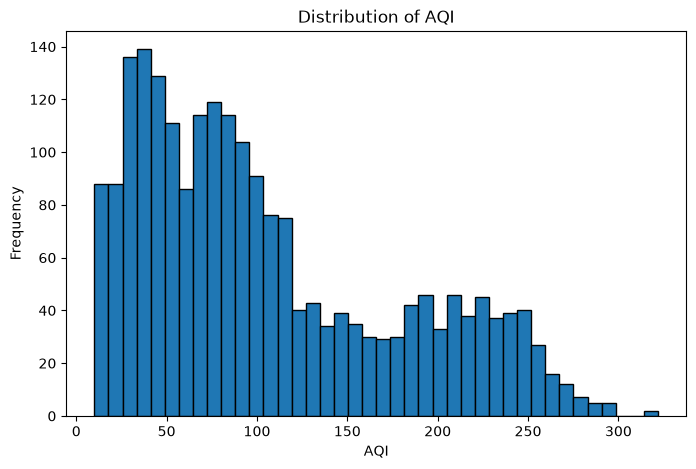

In [7]:
import pandas as pd
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))
plt.hist(df["aqi"], bins=40, edgecolor="black")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.title("Distribution of AQI")
plt.show()

In [8]:
df.columns

Index(['date', 'station', 'pm2_5', 'pm10', 'no2', 'so2', 'co', 'o3', 'nh3',
       'temperature_c', 'humidity_pct', 'wind_speed_kmph', 'pressure_hpa',
       'traffic_level', 'is_industrial_zone', 'aqi'],
      dtype='object')

In [9]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month


In [10]:
df["month_name"] = df["date"].dt.month_name()

In [11]:
df.head()

,date,station,pm2_5,pm10,no2,so2,co,o3,nh3,temperature_c,humidity_pct,wind_speed_kmph,pressure_hpa,traffic_level,is_industrial_zone,aqi,month,month_name
0,2023-10-17,Delhi_ITO,140.34,227.75,44.46,21.660000,1.187,38.81,14.02000,25.57,64.3,8.03,1005.3,high,True,184.4,10,October
1,2023-08-21,Shimla_Sanjauli,3.00,15.34,17.13,10.260000,0.424,64.81,14.99000,26.26,85.0,5.78,1003.4,low,False,10.0,8,August
2,2023-05-11,Shimla_Sanjauli,12.30,35.38,23.51,10.200000,0.916,38.49,17.20000,21.96,58.0,4.92,1012.0,low,False,35.4,5,May
3,2023-01-19,Delhi_RKPuram,171.45,386.78,62.14,20.440000,1.818,21.87,15.32526,19.43,49.1,2.07,1017.9,high,False,230.5,1,January
4,2023-12-25,Shimla_Sanjauli,24.00,50.84,46.89,18.420512,1.814,31.92,15.32526,7.98,38.4,9.35,1011.8,low,False,43.2,12,December


In [12]:
df.drop(columns=["date", "month_name"],inplace=True)

In [16]:
df.head()

,station,pm2_5,pm10,no2,so2,co,o3,nh3,temperature_c,humidity_pct,wind_speed_kmph,pressure_hpa,traffic_level,is_industrial_zone,aqi,month
0,1,140.34,227.75,44.46,21.660000,1.187,38.81,14.02000,25.57,64.3,8.03,1005.3,0,1,184.4,10
1,5,3.00,15.34,17.13,10.260000,0.424,64.81,14.99000,26.26,85.0,5.78,1003.4,1,0,10.0,8
2,5,12.30,35.38,23.51,10.200000,0.916,38.49,17.20000,21.96,58.0,4.92,1012.0,1,0,35.4,5
3,2,171.45,386.78,62.14,20.440000,1.818,21.87,15.32526,19.43,49.1,2.07,1017.9,0,0,230.5,1
4,5,24.00,50.84,46.89,18.420512,1.814,31.92,15.32526,7.98,38.4,9.35,1011.8,1,0,43.2,12


In [15]:
label = LabelEncoder()

df["station"] = label.fit_transform(df["station"])
df["traffic_level"] = label.fit_transform(df["traffic_level"])
df["is_industrial_zone"] = label.fit_transform(df["is_industrial_zone"])

<Axes: >

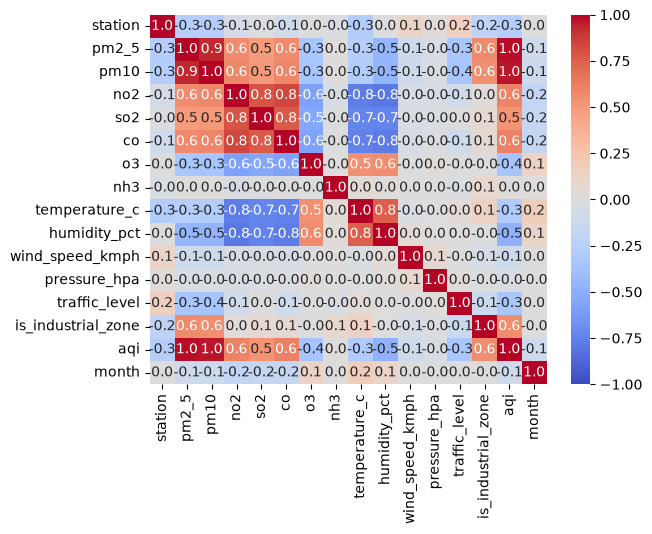

In [40]:
import seaborn as sns
var = df[['station', 'pm2_5', 'pm10', 'no2', 'so2', 'co', 'o3', 'nh3', 'temperature_c', 'humidity_pct', 'wind_speed_kmph', 'pressure_hpa','traffic_level', 'is_industrial_zone', 'aqi', 'month']].corr()

sns.heatmap(var, annot=True, cmap="coolwarm",vmax=1, vmin=-1, fmt=".1f")



In [25]:
df.head()

,station,pm2_5,pm10,no2,so2,co,o3,nh3,temperature_c,humidity_pct,wind_speed_kmph,pressure_hpa,traffic_level,is_industrial_zone,aqi,month
0,1,140.34,227.75,44.46,21.660000,1.187,38.81,14.02000,25.57,64.3,8.03,1005.3,0,1,184.4,10
1,5,3.00,15.34,17.13,10.260000,0.424,64.81,14.99000,26.26,85.0,5.78,1003.4,1,0,10.0,8
2,5,12.30,35.38,23.51,10.200000,0.916,38.49,17.20000,21.96,58.0,4.92,1012.0,1,0,35.4,5
3,2,171.45,386.78,62.14,20.440000,1.818,21.87,15.32526,19.43,49.1,2.07,1017.9,0,0,230.5,1
4,5,24.00,50.84,46.89,18.420512,1.814,31.92,15.32526,7.98,38.4,9.35,1011.8,1,0,43.2,12


In [27]:
x = df.drop(columns=["aqi"])
y =df["aqi"]

In [28]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
# scaling the data

scaler = StandardScaler()
x_train_scaled =  scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [30]:
best_par = {"max_depth" : [2,3,5,7,12], "n_estimators": [150,200,250,300,350], "learning_rate":[0.01,0.1,0.02,1,0.2]}

model = XGBRegressor(random_state=42)

grid_search= GridSearchCV(estimator=model,
                          param_grid=best_par,
                          cv=5,
                          n_jobs=-1,
                          verbose=1)

grid_search.fit(x_train_scaled,y_train)

Fitting 5 folds for each of 125 candidates, totalling 625 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [2, 3, ...], 'n_estimators': [150, 200, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [31]:
best_model = grid_search.best_estimator_

In [33]:
y_pred = best_model.predict(x_test_scaled)
r2_score(y_test, y_pred)

0.9693009012708382

In [35]:
# doing the accuracy test on train data
y_pred_train = best_model.predict(x_train_scaled)
r2_score(y_train,y_pred_train)

0.9928554748103121

In [37]:
print(grid_search.best_params_)

{'learning_rate': 0.02, 'max_depth': 5, 'n_estimators': 300}


In [38]:
# saving the model
joblib.dump(best_model, "AQI Predict Model.pkl")

['AQI Predict Model.pkl']